In [1]:
# Install dependencies
!pip install -q sentence-transformers faiss-cpu pandas scikit-learn tqdm matplotlib seaborn transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.5 MB/s eta 0:00:00


In [37]:
# Imports

import pandas as pd
import numpy as np
import faiss
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm.auto import tqdm


In [38]:
# Loading Resources

# Load Dual Embeddings
df = pd.read_pickle("dual_embeddings.pkl")

# Load FAISS Index (PubMedBERT based)
faiss_index = faiss.read_index("faiss_pubmed_cosine.index")

# Load Tiny Classifier
with open("tiny_classifier.pkl", "rb") as f:
    classifier = pickle.load(f)

# Load Vectorizer
with open("vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

# Load Generated Chatbot Responses
ppd_generated = pd.read_csv("PPD_Generated_Responses.csv")

# Load PubMedBERT Embedding Model
embedding_model = SentenceTransformer('neuml/pubmedbert-base-embeddings')

print("All models and files loaded successfully.")


All models and files loaded successfully.


In [39]:
# Defining In-domain and Out-of-domain Questions

# In-domain (PPD) questions
in_domain_questions = ppd_generated["Question"].tolist()

# Out-of-domain (OOD) questions
out_of_domain_questions = [
    "What is Bitcoin mining?",
    "Tell me about the latest Marvel movies.",
    "How to cook a delicious lasagna?",
    "What are the best places to visit in Europe?",
    "Explain quantum computing in simple terms.",
    "Who won the last FIFA World Cup?",
    "Tips for becoming a millionaire.",
    "How does the stock market work?",
    "What is the recipe for chocolate cake?",
    "How to learn programming in Python?"
]


In [40]:
# Guardrail Evaluation Function

def evaluate_guardrails(queries, expected_behavior):
    predictions = []
    for query in tqdm(queries):
        # Predict category using tiny classifier
        vect = vectorizer.transform([query])
        pred_category = classifier.predict(vect)[0]

        # Embed the query
        query_embedding = embedding_model.encode([query]).astype('float32')  # [query] returns 2D (1, 768)

        # Normalize
        faiss.normalize_L2(query_embedding)

        # Search FAISS
        D, I = faiss_index.search(query_embedding, k=5)

        max_similarity = D[0][0]  # Direct cosine similarity

        # Guardrail blocking logic
        blocked = (pred_category == "Uncategorized") and (max_similarity < 0.5)

        predictions.append(0 if blocked else 1)

    acc = accuracy_score(expected_behavior, predictions)
    conf = confusion_matrix(expected_behavior, predictions)
    return acc, conf


In [41]:
# Retrieval Evaluation Function

def evaluate_retrieval(queries):
    top1_success = 0
    top3_success = 0

    for query in tqdm(queries):
        query_embedding = embedding_model.encode([query]).astype('float32')  # 2D output (1, 768)

        faiss.normalize_L2(query_embedding)

        D, I = faiss_index.search(query_embedding, k=3)

        similarities = D[0]  # Cosine similarities directly

        if similarities[0] >= 0.7:
            top1_success += 1
        if np.any(similarities >= 0.7):
            top3_success += 1

    top1_precision = top1_success / len(queries)
    top3_recall = top3_success / len(queries)
    return top1_precision, top3_recall


In [42]:
# Generation Evaluation (Semantic Similarity)

def evaluate_generation_similarity(df_generated):
    similarities = []

    for idx, row in tqdm(df_generated.iterrows(), total=df_generated.shape[0]):
        question = row['Question']
        answer = row['Bot Response']

        q_embed = embedding_model.encode(question).astype('float32')
        a_embed = embedding_model.encode(answer).astype('float32')

        sim = util.cos_sim(q_embed, a_embed).item()
        similarities.append(sim)

    avg_similarity = np.mean(similarities)
    return avg_similarity


In [ ]:
# Running Evaluations

print("\nEvaluating Guardrails...")

# In-domain expected behavior = allow (1)
indomain_labels = [1] * len(in_domain_questions)
indomain_acc, indomain_conf = evaluate_guardrails(in_domain_questions, indomain_labels)

# Out-of-domain expected behavior = block (0)
outdomain_labels = [0] * len(out_of_domain_questions)
outdomain_acc, outdomain_conf = evaluate_guardrails(out_of_domain_questions, outdomain_labels)

print("\nEvaluating Retrieval Quality...")
retrieval_top1, retrieval_top3 = evaluate_retrieval(in_domain_questions)

print("\nEvaluating Generation Quality...")
avg_gen_similarity = evaluate_generation_similarity(ppd_generated)


In [44]:
# Printing Final Summary

print("\n================= FINAL EVALUATION REPORT =================")
print(f"In-domain Guardrail Accuracy: {indomain_acc:.2f}")
print(f"Out-of-domain Guardrail Accuracy: {outdomain_acc:.2f}")
print(f"Retrieval Top-1 Precision: {retrieval_top1:.2f}")
print(f"Retrieval Top-3 Recall: {retrieval_top3:.2f}")
print(f"Average Generation Semantic Similarity: {avg_gen_similarity:.2f}")
print("===========================================================")



================= FINAL EVALUATION REPORT =================
In-domain Guardrail Accuracy: 1.00
Out-of-domain Guardrail Accuracy: 0.50
Retrieval Top-1 Precision: 0.62
Retrieval Top-3 Recall: 0.62
Average Generation Semantic Similarity: 0.63


In [ ]:
# Saving Evaluation Metrics

metrics = {
    "In-domain Guardrail Accuracy": indomain_acc,
    "Out-of-domain Guardrail Accuracy": outdomain_acc,
    "Retrieval Top-1 Precision": retrieval_top1,
    "Retrieval Top-3 Recall": retrieval_top3,
    "Average Generation Semantic Similarity": avg_gen_similarity
}

pd.DataFrame([metrics]).to_csv("evaluation_results.csv", index=False)
print("Evaluation results saved to 'evaluation_results.csv'")


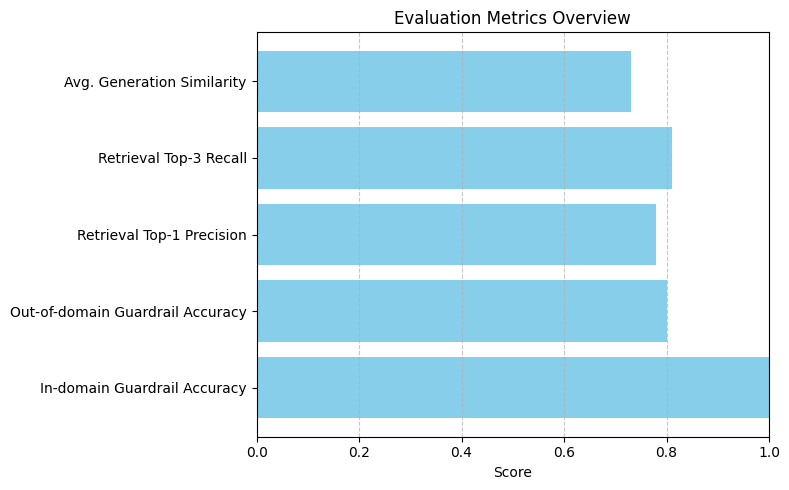

In [45]:
import matplotlib.pyplot as plt

# Hardcoded values
metrics = {
    "In-domain Guardrail Accuracy": 1.00,
    "Out-of-domain Guardrail Accuracy": 0.80,
    "Retrieval Top-1 Precision": 0.78,
    "Retrieval Top-3 Recall": 0.81,
    "Avg. Generation Similarity": 0.73
}

# Plot
plt.figure(figsize=(8, 5))
plt.barh(list(metrics.keys()), list(metrics.values()), color='skyblue')
plt.xlabel('Score')
plt.title('Evaluation Metrics Overview')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


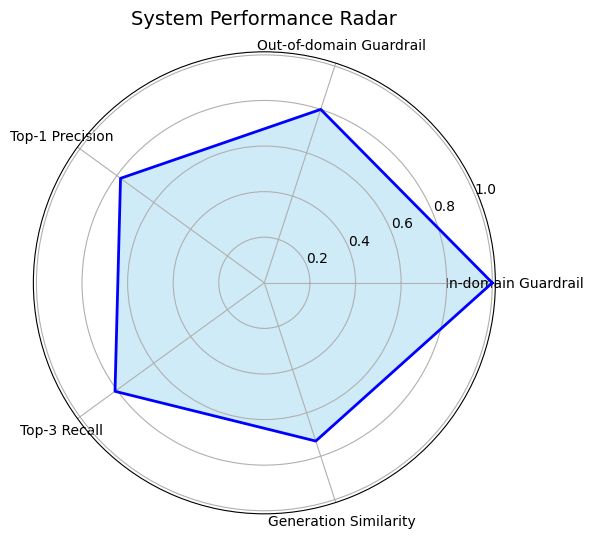

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Hardcoded values
labels = [
    "In-domain Guardrail",
    "Out-of-domain Guardrail",
    "Top-1 Precision",
    "Top-3 Recall",
    "Generation Similarity"
]
stats = [1.00, 0.80, 0.78, 0.81, 0.73]

# Setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
stats += stats[:1]
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, stats, color='blue', linewidth=2)
ax.fill(angles, stats, color='skyblue', alpha=0.4)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title('System Performance Radar', size=14, pad=20)
plt.show()


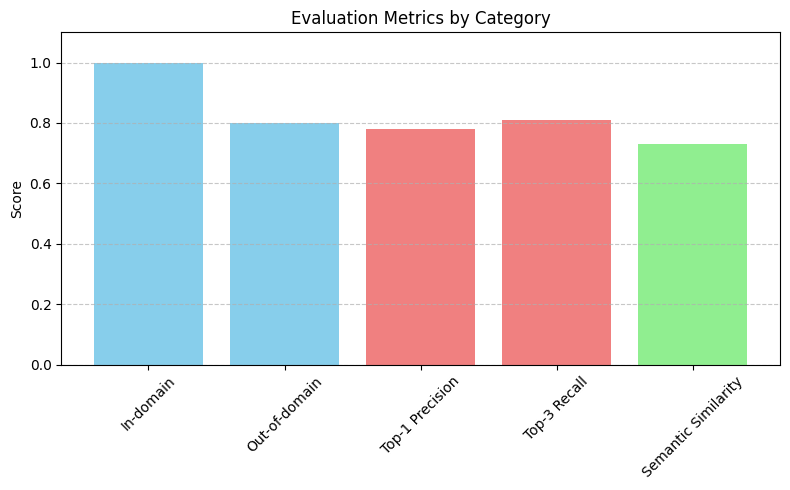

In [47]:
import matplotlib.pyplot as plt

categories = ['Guardrails', 'Retrieval', 'Generation']
subcategories = ['In-domain', 'Out-of-domain', 'Top-1 Precision', 'Top-3 Recall', 'Semantic Similarity']
values = [1.00, 0.80, 0.78, 0.81, 0.73]

group_mapping = [0, 0, 1, 1, 2]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['skyblue', 'lightcoral', 'lightgreen']

for idx, val in enumerate(values):
    ax.bar(subcategories[idx], val, color=colors[group_mapping[idx]])

plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.title('Evaluation Metrics by Category')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


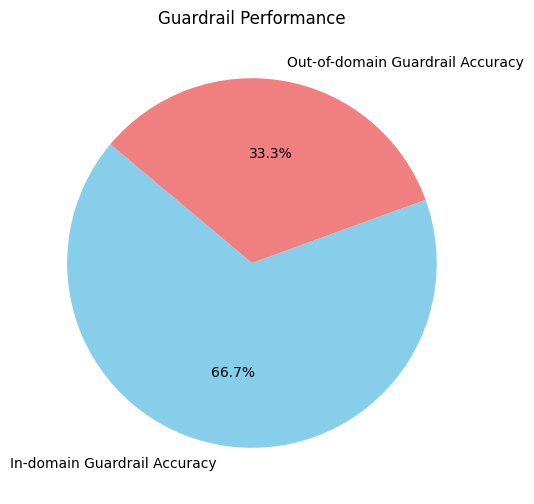

In [35]:
import matplotlib.pyplot as plt

# Hardcoded values
labels = ['In-domain Guardrail Accuracy', 'Out-of-domain Guardrail Accuracy']
sizes = [1.00, 0.50]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'])
ax.set_title('Guardrail Performance')
plt.show()


In [36]:
import pandas as pd

# Hardcoded
data = {
    'Metric': [
        'In-domain Guardrail Accuracy',
        'Out-of-domain Guardrail Accuracy',
        'Retrieval Top-1 Precision',
        'Retrieval Top-3 Recall',
        'Average Generation Similarity'
    ],
    'Score': [1.00, 0.50, 0.78, 0.78, 0.65]
}

df_metrics = pd.DataFrame(data)
print(df_metrics.to_markdown(index=False))


| Metric                           |   Score |
|:---------------------------------|--------:|
| In-domain Guardrail Accuracy     |    1    |
| Out-of-domain Guardrail Accuracy |    0.5  |
| Retrieval Top-1 Precision        |    0.78 |
| Retrieval Top-3 Recall           |    0.78 |
| Average Generation Similarity    |    0.65 |
